In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
os.chdir('../')
import yaml
import torch
import torch.nn as nn
import numpy as np
import ecg_plot 
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from module.IBExtractor import IBExtractor
from diffusers import DDPMScheduler
from transformers import AutoModel, AutoTokenizer
from tqdm import tqdm
from utils.model_utils import build_noise_predictor
from utils.data_utils import process_pat_info, get_text_embedding, sex_transform
from scipy.ndimage import gaussian_filter1d

/home/laiyongfan/miniconda3/envs/Eren/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ckpt_path = './checkpoints/DiT_ECGTwin_novae_1/DiT_ECGTwin_best.pth'
device_str = 'cuda:1'

config_path = "config/novae_DiT_ECGTwin.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f) 

h_ = config['hyper_para']
model_type = config['meta']['model_type']
save_path = f'exp/batch_{model_type}'

meta = config['meta']
roots = config['dependencies']
h_ = config['hyper_para']
settings = config['inference_setting']

use_vae_latent = meta['vae_latent']     
n_channels = 4 if use_vae_latent else 12 

prerequisites = {}
prerequisites['tar'] = settings

reference_data = torch.load("data/prepared_input/normal_1.pt")
prerequisites['ref_latent'] = reference_data['data']
prerequisites['ref'] = reference_data['label']
batch = prerequisites['tar']['gen_batch']

In [3]:
device = torch.device(device_str if torch.cuda.is_available() else "cpu")
noise_predictor = build_noise_predictor(meta['model_type'], n_channels, h_)
noise_predictor_ckpt = torch.load(ckpt_path, map_location=device)
noise_predictor.load_state_dict(noise_predictor_ckpt)
noise_predictor.eval()
noise_predictor.to(device)

diffused_model = DDPMScheduler(num_train_timesteps=h_['ddpm']['num_train_steps'], beta_start=h_['ddpm']['beta_start'], beta_end=h_['ddpm']['beta_end'])
diffused_model.set_timesteps(settings['inference_timestep'])

ibe_model = IBExtractor(embed_dim=h_['ibe']['embed_dim'], num_heads=h_['ibe']['num_heads'], ff_hidden_size=h_['ibe']['ff_hidden_size'], num_layers=h_['ibe']['num_layers'], text_embed_dim=h_['ibe']['text_embed_dim'], patient_info_size=h_['ibe']['patient_info_size'])
ibe_model.load_state_dict(torch.load(roots['ibe_path'], map_location='cpu'))
ibe_model.eval()
ibe_model.to(device)

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
embedding_model = AutoModel.from_pretrained('nomic-ai/nomic-embed-text-v1.5', trust_remote_code=True, safe_serialization=True)
embedding_model.to(device)
embedding_model = embedding_model.eval()

<All keys matched successfully>


In [24]:
pat_info_ref = process_pat_info(normalize=True,
                                hr=torch.tensor([prerequisites['ref']['hr']]),
                                age=torch.tensor([prerequisites['ref']['age']]),
                                sex=torch.tensor([sex_transform(prerequisites['ref']['sex'])]))

pat_info_ref = pat_info_ref.repeat(batch, 1).to(device)

# (B, num_reports, 768)
text_embed_ref = prerequisites['ref']['text_embed'].unsqueeze(0).repeat(batch, 1, 1).to(device)

# (B, L, C)
latent_ref = prerequisites['ref_latent'].unsqueeze(0).repeat(batch, 1, 1).transpose(2, 1).to(device)

# (B, L, bv_dim)
base_vector = ibe_model.extract_features(latent_ref, text_embed_ref, None, pat_info_ref, reduce=True)
# base_vector = torch.zeros_like(base_vector, device=device)

text_embed_tar = get_text_embedding(text=prerequisites['tar']['text'],
                                    tokenizer=tokenizer,
                                    embedding_model=embedding_model,
                                    mix=config['meta']['mix'])
text_embed_tar = text_embed_tar.unsqueeze(0).repeat(batch, 1, 1)

pat_info_tar = process_pat_info(normalize=True,
                                add_token=False,
                                hr=torch.tensor([prerequisites['tar']['hr']]),
                                age=torch.tensor([prerequisites['tar']['age']]),
                                sex=torch.tensor([sex_transform(prerequisites['ref']['sex'])]))
pat_info_tar = pat_info_tar.repeat(batch, 1).to(device)


In [5]:
with torch.no_grad():
    xi = torch.randn(batch, 12, 1024)
    xi = xi.to(device)
    timesteps = tqdm(diffused_model.timesteps)
    for _, i in enumerate(timesteps):
        t = i*torch.ones(batch, dtype=torch.long, device=device)

        # if i == settings['inference_timestep'] - 1:
        if i == 100:
            predicted_noise, attn_map_list = noise_predictor(xi, t, text_embed_tar, None, pat_info_tar, base_vector, need_weights=True)
        else:
            predicted_noise = noise_predictor(xi, t, text_embed_tar, None, pat_info_tar, base_vector, need_weights=False)


        xi = diffused_model.step(model_output=predicted_noise, 
                                    timestep=i, 
                                    sample=xi)['prev_sample']


batch_gen_ecg = xi.cpu().detach().numpy()

100%|██████████| 1000/1000 [00:30<00:00, 32.34it/s]


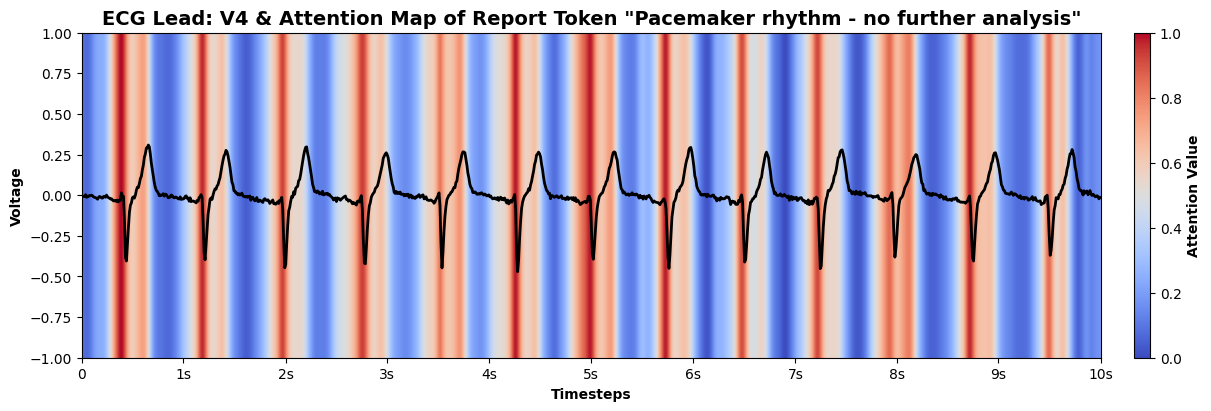

In [ ]:
# attn_map: (B, l_q, l_k)
sample_ids = 4
lead_ids = 9
token_ids = 1
focus_report_token = prerequisites['tar']['text'].split('|')[token_ids]
# layer_ids = 5
# attn_map_token = attn_map_list[layer_ids][sample_ids, :, token_ids].cpu().detach().numpy()
attn_map_token = torch.stack(attn_map_list).mean(dim=0)[sample_ids, :, token_ids].cpu().detach().numpy()
original_signal = batch_gen_ecg[sample_ids, lead_ids, :]

sigma = 3
attn_map_smoothed = gaussian_filter1d(attn_map_token, sigma)

attn_map_normalized = (attn_map_smoothed - attn_map_smoothed.min()) / (attn_map_smoothed.max() - attn_map_smoothed.min())

lead_name = ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
# Original signal
ax.plot(original_signal, label=f'Lead: {lead_name[lead_ids]}', color='black', linewidth=2)

cmap = plt.get_cmap('coolwarm')  
norm = mcolors.Normalize(vmin=0, vmax=1)  

# heatmap as bg
for i in range(len(original_signal)):
    color = cmap(norm(attn_map_normalized[i]))
    ax.axvspan(i - 2.5, i + 2.5, facecolor=color, alpha=0.7, edgecolor=None)

# color bar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Attention Value', weight="bold")

# plt.legend(prop={"weight": "bold"})
plt.title(f'ECG Lead: {lead_name[lead_ids]} & Attention Map of Report Token "{focus_report_token}"', fontsize=14, weight='bold')
plt.xlabel('Timesteps', fontsize=10, weight='bold')
plt.xlim(0, 1024)
plt.xticks(ticks=[0, 102, 205, 307, 409, 512, 614, 717, 819, 921, 1024], 
           labels=['0', '1s', '2s', '3s', '4s', '5s', '6s', '7s', '8s', '9s', '10s'])
# plt.xlim(0, 512)
# plt.xticks(ticks=[0, 102, 205, 306, 409, 512], labels=['0', '1s', '2s', '3s', '4s', '5s'])

plt.ylim(-1, 1)
plt.ylabel('Voltage', fontsize=10, weight='bold')
# plt.savefig(f'figure/attn_map/pacemaker_{lead_name[lead_ids]}.pdf', dpi=300)
plt.show()

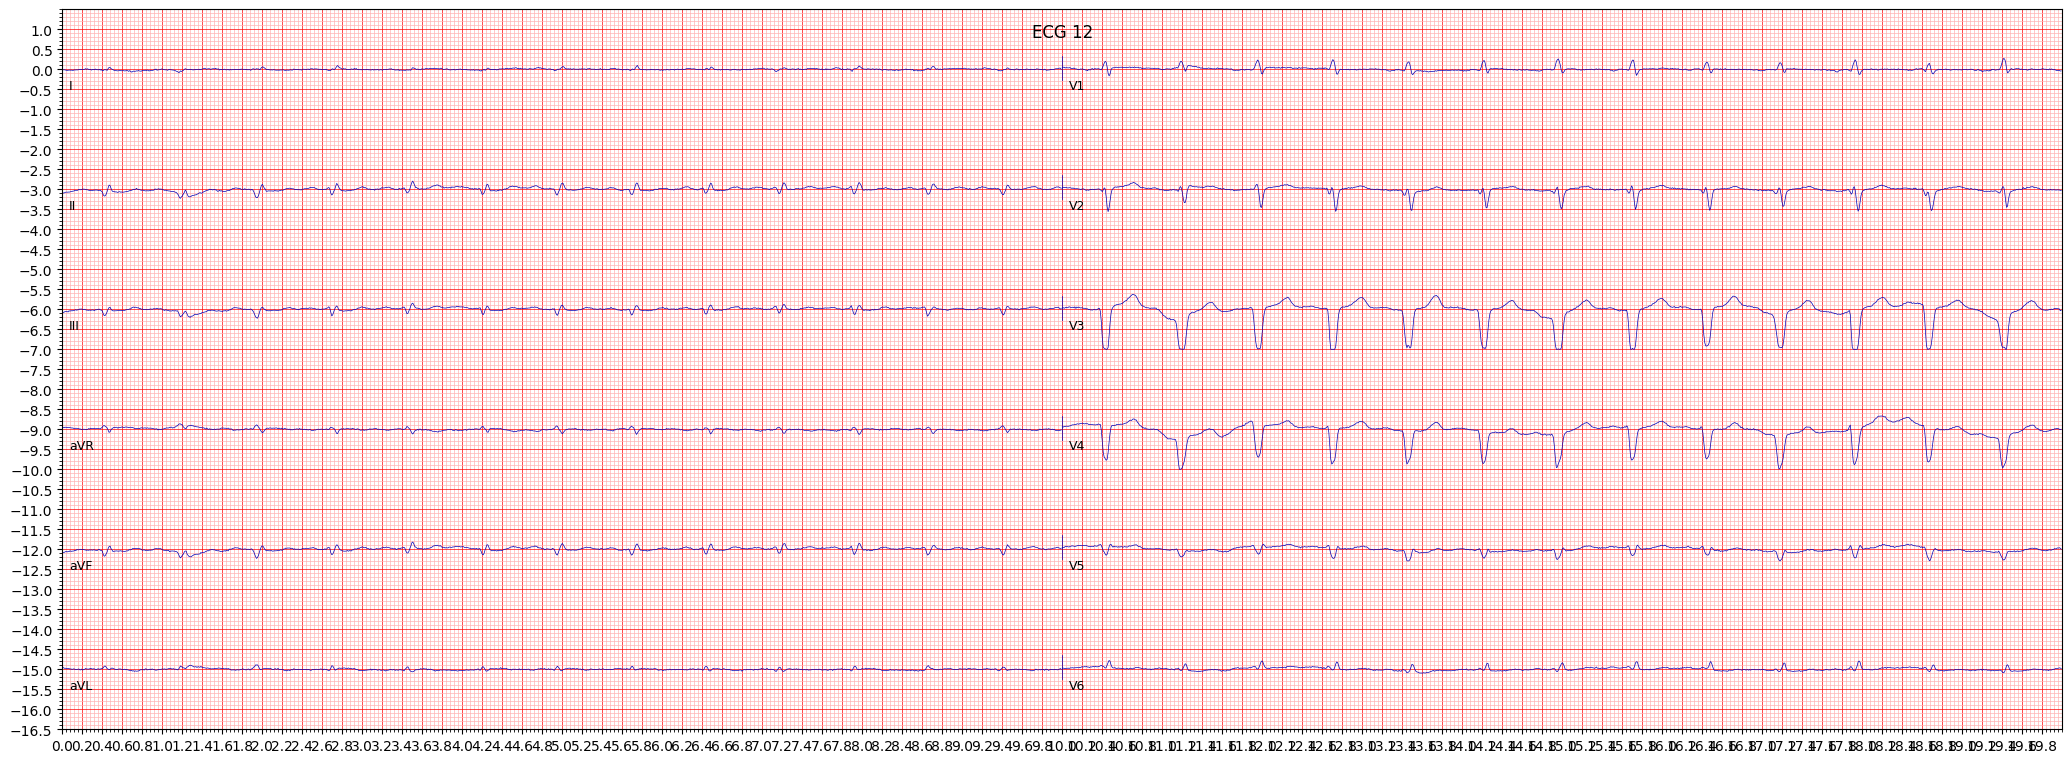

In [12]:
generated_ecg = batch_gen_ecg[sample_ids]
# (C, L)
ecg_plot.plot(generated_ecg, 102.4, lead_index=lead_name) 
plt.show()

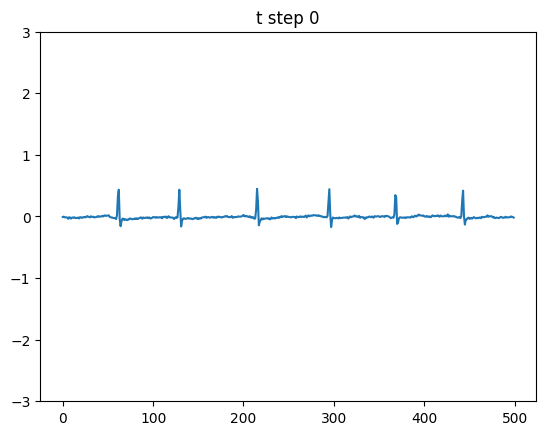

In [ ]:
def forward_process(ecg, 
                    num_steps: int, 
                    num_frame: int):
    
    from matplotlib.animation import FuncAnimation

    diffused_model = DDPMScheduler(num_train_timesteps=num_steps, beta_start=0.00085, beta_end=0.0120)
    skip = num_steps // num_frame
    fig, ax = plt.subplots()
    ax.set_ylim(-3, 3)
    ax.set_title('t step 0')
    length = 500
    x = range(length)
    line, = ax.plot(x, ecg[0, 0, :length])

    def update(i):
        t = torch.tensor(i * skip, dtype=int)
        noise = torch.randn(ecg.shape)
        noised_ecg = diffused_model.add_noise(torch.tensor(ecg), noise, t)[0, 0, :length]
        line.set_ydata(noised_ecg)
        ax.set_title(f't step {t}')
        return line, ax 
    
    ani = FuncAnimation(fig, update, frames=num_frame)
    plt.show()
    ani.save('ff.gif', writer="pillow")


forward_process(ecg=generated_ecg, num_steps=1000, num_frame=50)

100%|██████████| 1000/1000 [00:44<00:00, 22.32it/s]


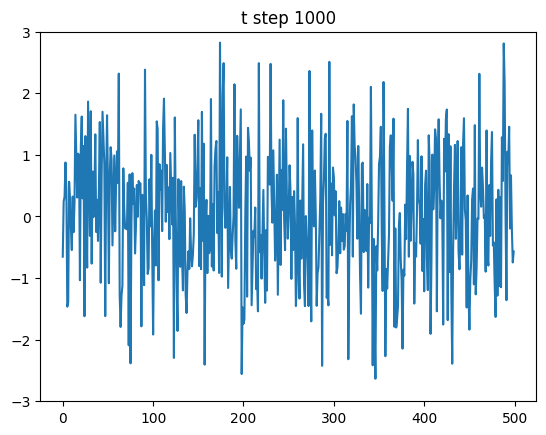

In [13]:
@torch.no_grad
def backward_process(num_steps: int, 
                     num_frame: int):
    
    from matplotlib.animation import FuncAnimation
    skip = num_steps // num_frame
    fig, ax = plt.subplots()
    xi_list = []
    xi = torch.randn(1, 12, 1024)
    xi_list.append(xi.cpu().detach().numpy())

    ax.set_ylim(-3, 3)
    length = 500
    x_ticks = range(length)
    line, = ax.plot(x_ticks, xi[0, 0, :length])

    xi = xi.to(device)
    timesteps = tqdm(diffused_model.timesteps)
    ax.set_title(f't step {len(timesteps)}')
    for _, i in enumerate(timesteps):
        t = i*torch.ones(batch, dtype=torch.long, device=device)
        predicted_noise = noise_predictor(xi, t, text_embed_tar, None, pat_info_tar, base_vector, need_weights=False)
        xi = diffused_model.step(model_output=predicted_noise, 
                                    timestep=i, 
                                    sample=xi)['prev_sample']

        xi_list.append(xi.cpu().detach().numpy())

    def update(i):
        line.set_ydata(xi_list[950 + i][0, 0, :length])
        ax.set_title(f't step {50 - i}')
        return line, ax 
    
    ani = FuncAnimation(fig, update, frames=num_frame)
    plt.show()
    ani.save('bw.gif', writer="pillow")


backward_process(num_steps=1000, num_frame=50)

In [18]:
from module.vae_model import VAE_Decoder
import copy

decoder = VAE_Decoder()
vae_path = config['dependencies']['vae_path']
vae_checkpoint = torch.load(vae_path, map_location=device)
decoder.load_state_dict(vae_checkpoint['decoder'])
decoder.to(device)
decoder.eval()

lead_name = ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [39]:
reference_data['label']

{'text': 'Sinus rhythm|Normal ECG',
 'subject_id': 10000117,
 'hr': 91.22807017543859,
 'ecg_time': '2181-03-04 17:14:00',
 'sex': 'F',
 'age': 55,
 'text_embed': tensor([[ 0.0496,  0.0138, -0.1832,  ..., -0.0567, -0.0357,  0.0113],
         [ 0.0347,  0.0333, -0.1795,  ..., -0.0384, -0.0351,  0.0341]])}

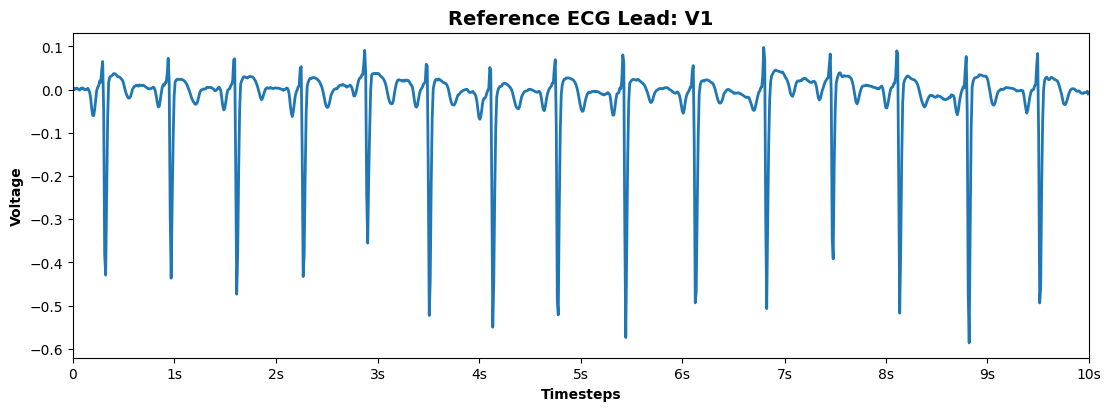

In [36]:
# attn_map: (B, l_q, l_k)
sample_ids = 4
lead_ids = 6
token_ids = 1
decoder_input = copy.deepcopy((latent_ref.transpose(2, 1)))
original_signal = decoder(decoder_input).transpose(2, 1)[sample_ids, lead_ids, :].detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
# Original signal
ax.plot(original_signal, label=f'Lead: {lead_name[lead_ids]}', linewidth=2)

# plt.legend(prop={"weight": "bold"})
plt.title(f'Reference ECG Lead: {lead_name[lead_ids]}', fontsize=14, weight='bold')
plt.xlabel('Timesteps', fontsize=10, weight='bold')
plt.xlim(0, 1024)
plt.xticks(ticks=[0, 102, 205, 307, 409, 512, 614, 717, 819, 921, 1024], 
           labels=['0', '1s', '2s', '3s', '4s', '5s', '6s', '7s', '8s', '9s', '10s'])
# plt.xlim(0, 512)
# plt.xticks(ticks=[0, 102, 205, 306, 409, 512], labels=['0', '1s', '2s', '3s', '4s', '5s'])

# plt.ylim(-1, 1)
plt.ylabel('Voltage', fontsize=10, weight='bold')
plt.savefig(f'figure/attn_map/ref_{lead_name[lead_ids]}.pdf', dpi=300)
plt.show()